**Edited on 2026/5/15**

Validation Results
Best Threshold: 0.9300000000000002
Best Fraud F1: 0.7509881422924901
Confusion Matrix:
 [[7842   42]
 [  21   95]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      7884
           1       0.69      0.82      0.75       116

    accuracy                           0.99      8000
   macro avg       0.85      0.91      0.87      8000
weighted avg       0.99      0.99      0.99      8000


AUC-ROC Score: 0.9852243303766686
PR-AUC Score: 0.6441540638976792


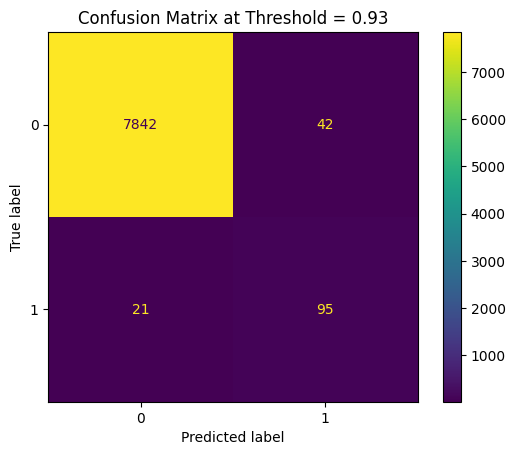

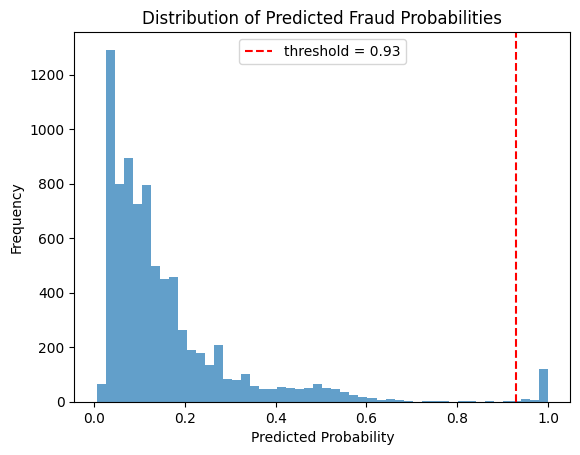

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    f1_score,
)

from xgboost import XGBClassifier

# read data
file_name = "/content/drive/MyDrive/DataMining/hw1/train_data.csv"
df_ds = pd.read_csv(file_name)

# split features and target
x = df_ds.drop(columns=["fraud"])
y = df_ds["fraud"]

# stratified split keeps the fraud ratio similar in train and validation sets
x_train, x_val, y_train, y_val = tts(
    x,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

categorical_features = ["att3", "att6", "att7", "att8", "att9"]
numerical_features = ["att4", "att5", "att10", "att12", "att13", "att15", "att16"]

# normalize numerical features and one-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# calculate class imbalance ratio from the training set
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = 41 # tuned value; lower than the raw imbalance ratio because SMOTEENN already adjusts class distribution

pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smoteenn", SMOTEENN(random_state=0, sampling_strategy=0.3)),
    ("classifier", XGBClassifier(
        random_state=0,
        scale_pos_weight=scale_pos_weight,
        n_estimators=300,
        learning_rate=0.023,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="aucpr",
    ))
])

# training
pipeline.fit(x_train, y_train)

# prediction probability
y_proba = pipeline.predict_proba(x_val)[:, 1]

# threshold tuning based on fraud-class F1 score
best_threshold = 0
best_f1 = 0

for threshold in np.arange(0.80, 0.96, 0.01):
    y_pred_t = (y_proba >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

# final prediction using the best threshold
y_pred = (y_proba >= best_threshold).astype(int)

# model evaluation
print("Validation Results")
print("Best Threshold:", best_threshold)
print("Best Fraud F1:", best_f1)
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nAUC-ROC Score:", roc_auc_score(y_val, y_proba))
print("PR-AUC Score:", average_precision_score(y_val, y_proba))

ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
plt.title(f"Confusion Matrix at Threshold = {best_threshold:.2f}")
plt.show()

plt.hist(y_proba, bins=50, alpha=0.7)
plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"threshold = {best_threshold:.2f}"
)
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Fraud Probabilities")
plt.legend()
plt.show()
